# 실습 과제 2 — 환경 요인 기반 일별 자전거 대여량 예측 회귀모델 구축 및 해석
**UCI Bike Sharing Dataset (day.csv, 731건) · 범주형 포함 다중선형회귀**

> 4단계 구조: ① 문제 정의·변수 설계 → ② EDA·전처리 → ③ 모델 구축·성능 평가 → ④ 결과 해석·보고

---
## 1단계. 문제 정의 및 변수 설계 *(설계역량 15점)*

**분석 목적 (한 문장)**
> 날씨·계절·요일 등 환경 요인으로 일별 자전거 대여량(cnt)을 예측하고, 수요 변동의 핵심 요인을 식별하여 자전거 재배치·인력 운영 계획에 활용한다.

**변수 설계 근거**

| 구분 | 변수 | 유형 | 근거 |
|---|---|---|---|
| 종속변수(y) | `cnt` | 연속 | 일별 총 대여량 = 운영 수요 |
| 연속형 X | `temp, hum, windspeed` | 연속 | 기온·습도·풍속 등 이용에 직접 영향 |
| 범주형 X | `season, weathersit, weekday, mnth, holiday, workingday, yr` | 범주 | 계절·날씨상태·요일 패턴 |
| **제외** | `casual, registered` | — | **cnt = casual + registered** 이므로 사용 시 정답 누설(데이터 누수) |
| 제외 | `instant, dteday, atemp` | — | 식별자·날짜 / atemp는 temp와 거의 완전 상관 |

**행동3 근거:** `casual`(비회원)과 `registered`(회원)의 합이 종속변수 `cnt`이므로 독립변수로 넣으면 R²가 인위적으로 1에 가까워지는 **타깃 누수(leakage)**가 발생한다. 반드시 제외한다.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
plt.rcParams['figure.figsize']=(7,4); sns.set_style('whitegrid')

# 한글 폰트 (Windows: Malgun Gothic / macOS: AppleGothic / Colab: NanumGothic)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

# 강사 지정 소스로 Bike Sharing 로드
df=pd.read_csv('https://raw.githubusercontent.com/oriolramospuig/bikeSharingCSV/main/day.csv')
print(df.shape, '| 결측:', df.isna().sum().sum())     # (731, 16)
print('temp-atemp 상관:', df['temp'].corr(df['atemp']).round(3))  # 0.992 → 둘 중 temp만 사용
df.head()

(731, 16) | 결측: 0
temp-atemp 상관: 0.992


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 2단계. 데이터 탐색(EDA) 및 전처리 *(설계역량 15점)*

**행동1 — cnt 분포 및 계절별·날씨별 평균 대여량 비교**

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


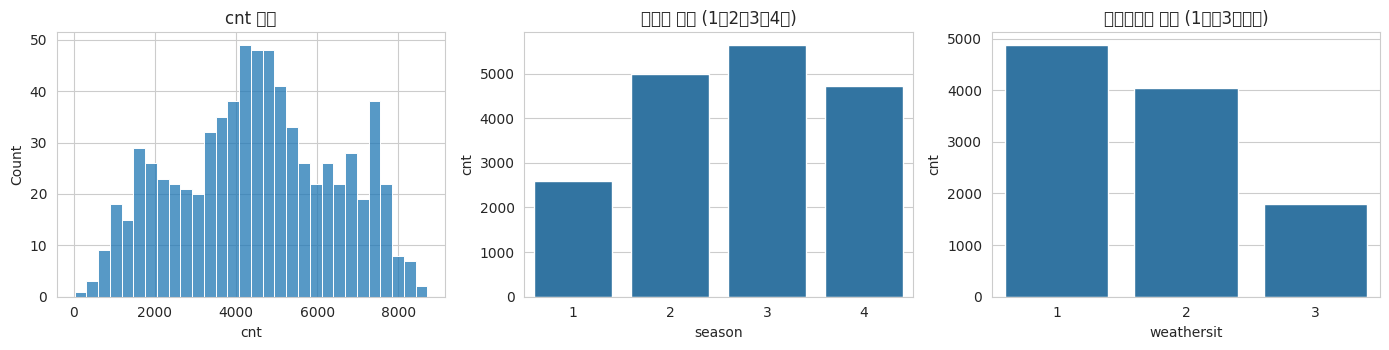

계절별 평균: {1: 2604.0, 2: 4992.0, 3: 5644.0, 4: 4728.0}
날씨별 평균: {1: 4877.0, 2: 4036.0, 3: 1803.0}


In [2]:
fig,ax=plt.subplots(1,3,figsize=(14,3.6))
sns.histplot(df['cnt'],bins=30,ax=ax[0]); ax[0].set_title('cnt 분포')
sns.barplot(x='season',y='cnt',data=df,ax=ax[1],errorbar=None); ax[1].set_title('계절별 평균 (1봄2여3가4겨)')
sns.barplot(x='weathersit',y='cnt',data=df,ax=ax[2],errorbar=None); ax[2].set_title('날씨상태별 평균 (1맑음3악천후)')
plt.tight_layout(); plt.show()

print('계절별 평균:', df.groupby('season')['cnt'].mean().round(0).to_dict())
print('날씨별 평균:', df.groupby('weathersit')['cnt'].mean().round(0).to_dict())

> 가을(3)이 최대(5,644대), 봄(1)이 최소(2,604대). 악천후(weathersit=3) 평균 1,803대로 맑음(4,877대)의 37% 수준까지 급감.

**행동2 — 기온과 대여량 산점도로 관계 형태(선형/비선형) 관찰**

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


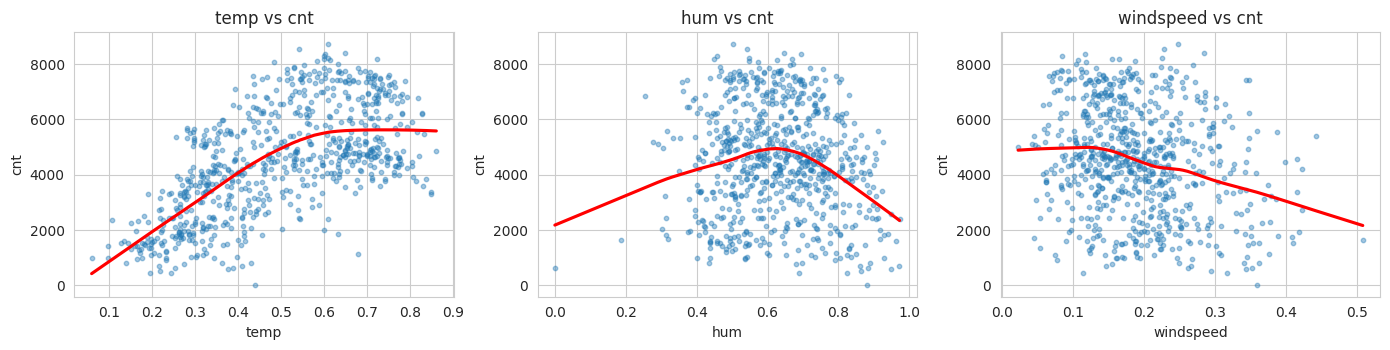

상관: {'temp': 0.627, 'hum': -0.101, 'windspeed': -0.235}


In [3]:
cont=['temp','hum','windspeed']
fig,ax=plt.subplots(1,3,figsize=(14,3.6))
for a,v in zip(ax,cont):
    sns.regplot(x=df[v],y=df['cnt'],ax=a,scatter_kws={'s':10,'alpha':.4},
                lowess=True,line_kws={'color':'red'})
    a.set_title(f'{v} vs cnt')
plt.tight_layout(); plt.show()
print('상관:', df[cont+['cnt']].corr()['cnt'][cont].round(3).to_dict())

> 기온(temp)은 대여량과 강한 양의 관계(r=0.63)지만 **고온 구간에서 증가세가 완만해지는 약한 비선형**이 관찰된다. 습도·풍속은 음의 관계.

**행동3 — 범주형 변수 원-핫 인코딩(더미변수) 변환**

In [4]:
cat=['season','weathersit','weekday','mnth']   # 다범주 → 원핫
bina=['holiday','workingday','yr']              # 이미 0/1
X=pd.get_dummies(df[cat+cont+bina].astype({k:'category' for k in cat}),
                 columns=cat, drop_first=True).astype(float)
y=df['cnt']
print('원핫 후 feature 수:', X.shape[1]); print(list(X.columns))

원핫 후 feature 수: 28
['temp', 'hum', 'windspeed', 'holiday', 'workingday', 'yr', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']


## 3단계. 회귀모델 구축 및 성능 평가 *(설계·평가전략 20점 + 구축·성능 20점)*

**행동1 — 8:2 분할 후 다중선형회귀. 단순회귀(temp)와 비교.**

> **왜 statsmodels OLS인가:** sklearn `LinearRegression`은 계수·예측만 제공하지만, 이 과제는 *변수 영향력·유의성 해석*이 핵심이다. statsmodels `sm.OLS`는 각 계수의 **표준오차·t값·p-value·95% 신뢰구간**과 모형 전체의 **F-검정·조정 R²**를 함께 제공해, 어떤 변수가 통계적으로 유의하며 얼마나 영향을 주는가를 근거와 함께 해석할 수 있다. 성능 지표(R²·RMSE·MAE)는 test set 예측으로 별도 산출한다.

In [5]:
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)

# 해석 중심 과제이므로 statsmodels OLS 사용 (p-value·신뢰구간·F검정 제공)
def evaluate_ols(cols, name):
    Xtr_c=sm.add_constant(Xtr[cols]); Xte_c=sm.add_constant(Xte[cols], has_constant='add')
    model=sm.OLS(ytr, Xtr_c).fit()
    p=model.predict(Xte_c)
    return {'model':name,
            'Test R2':round(r2_score(yte,p),3),
            'Test RMSE':round(np.sqrt(mean_squared_error(yte,p)),1),
            'Test MAE':round(mean_absolute_error(yte,p),1),
            'Train adjR2':round(model.rsquared_adj,3)}, model

r1,_        =evaluate_ols(['temp'], '① 단순(temp)')
r2_,ols_full=evaluate_ols(list(X.columns), '② 다중(전체)')
pd.DataFrame([r1,r2_])

,model,Test R2,Test RMSE,Test MAE,Train adjR2
0,① 단순(temp),0.404,1546.3,1292.0,0.387
1,② 다중(전체),0.841,798.3,584.5,0.839


**행동2 — 지표 선정 근거**

| 지표 | 의미 | 운영 관점 선정 이유 |
|---|---|---|
| **R²** | 수요 변동 설명 비율 | 환경 요인으로 수요를 얼마나 설명하는지 |
| **RMSE** | 오차 제곱평균 제곱근(대수) | 대량 결품/과잉 등 **큰 오차**에 민감 → 피크 대응 |
| **MAE** | 평균 절대오차(대수) | **재배치·인력 계획엔 평균적 오차 크기가 중요** → MAE 병행 |

> 단순(temp) R² 0.40 → 다중 R² 0.84로 대폭 향상. MAE 약 585대 → 하루 평균 예측이 약 585대 오차 수준. 일 평균 대여량(≈4,500대) 대비 약 13%.

**행동3 — 예측값 vs 실제값 산점도 (과소/과대 예측 구간 확인)**

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


...

findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


findfont: Font family 'Malgun Gothic' not found.


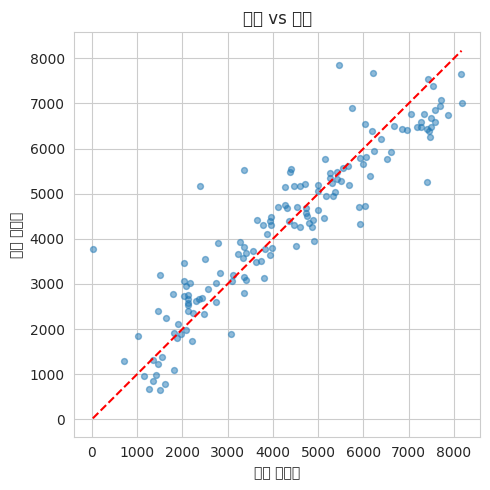

저수요 구간(<2000)에서 과대예측, 초고수요 구간에서 과소예측 경향 확인


In [6]:
pred=ols_full.predict(sm.add_constant(Xte[X.columns], has_constant='add'))
plt.figure(figsize=(5,5))
plt.scatter(yte,pred,alpha=.5,s=18)
lim=[yte.min(),yte.max()]; plt.plot(lim,lim,'r--')
plt.xlabel('실제 대여량'); plt.ylabel('예측 대여량'); plt.title('예측 vs 실제')
plt.tight_layout(); plt.show()
print('저수요 구간(<2000)에서 과대예측, 초고수요 구간에서 과소예측 경향 확인')

## 4단계. 결과 해석 및 보고서 작성 *(결과해석 20점 + 보고서 10점)*

**행동1·2 — 회귀계수 해석 및 유의 변수 식별**

In [7]:
# 전체 다중회귀 statsmodels summary (계수·p-value·신뢰구간·F검정)
print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     113.7
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          1.40e-206
Time:                        07:19:20   Log-Likelihood:                -4694.5
No. Observations:                 584   AIC:                             9445.
Df Residuals:                     556   BIC:                             9567.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1343.6165    265.030      5.070   

In [8]:
# 해석용 요약: 계수 크기순 정렬 + 유의변수 식별
tab=pd.DataFrame({'계수':ols_full.params.round(1),
                  'p-value':ols_full.pvalues.round(4),
                  '유의':np.where(ols_full.pvalues<0.05,'★','-')})
display(tab.sort_values('계수'))
print(f'조정 R²={ols_full.rsquared_adj:.3f} | F-검정 p={ols_full.f_pvalue:.2e}')

,계수,p-value,유의
windspeed,-2638.9,0.0000,★
weathersit_3,-1839.5,0.0000,★
hum,-1430.2,0.0000,★
weathersit_2,-509.3,0.0000,★
mnth_7,-285.0,0.4230,-
holiday,-218.2,0.2502,-
mnth_11,-212.7,0.4251,-
mnth_12,-189.8,0.3712,-
weekday_1,-56.4,0.4923,-
weekday_2,-37.0,0.6728,-


조정 R²=0.839 | F-검정 p=1.40e-206


### 결과 해석 요약 (운영 언어)

**영향력이 크고 유의한 변수 (p<0.05)**
- `temp`(계수 +4,886): 기온이 수요의 **최대 동인**. 정규화 기온 1단위(0→1, 약 0~41℃)당 대여량 크게 증가.
- `weathersit_3`(악천후, −1,840): 맑음 대비 **하루 약 1,840대 급감**.
- `weathersit_2`(흐림/안개, −509), `windspeed`(−2,639), `hum`(−1,430): 악조건마다 수요 감소.
- `yr`(+1,980): 2012년이 2011년보다 서비스 성장으로 큰 폭 증가.
- `season_4`(겨울 계절효과, 기온 통제 후 +1,655), `season_2/3` 유의: 기온 외 계절 자체 효과 존재.
- `workingday`(+350), `weekday_6`(토, +486): 근무일·주말 이용 패턴.

### 운영 의사결정 인사이트 (2가지 이상)

1. **기온·날씨 기반 재배치·인력 증원 트리거.** 기온이 수요 최대 동인이고 악천후는 하루 약 1,840대 수요를 깎는다 → **맑고 따뜻한 날은 사전 재배치·인력 증원, 악천후 예보일은 인력·정비 축소**로 운영비를 최적화할 수 있다.
2. **프로모션은 비수기(봄·저기온)·저수요일에 집중.** 봄(season 1)과 저기온·고습·강풍 구간의 수요가 구조적으로 낮다 → 이 구간에 할인·이벤트를 배치하면 수요 평탄화 효과가 크다. 이미 수요가 포화되는 가을 성수기 프로모션은 한계효용이 낮다.
3. (참고) 연도 계수(+1,980)로 확인된 성장 추세를 감안해, 내년 수요 베이스라인을 상향 조정한 인력·차량 규모 계획이 필요하다.